# ImageNet Baseline - Simple ResNet

This notebook implements a simple baseline on ImageNet using a ResNet architecture.


In [1]:
# Global preparations
import sys
import os
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import numpy as np

device = 'cuda:7'
random_seed = 1
torch.manual_seed(random_seed)
np.random.seed(random_seed)
torch.backends.cudnn.enabled = True
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.1.2+cu121
Device: cuda:7


## Data Loading

ImageNet dataset loading with standard augmentations for training and validation.


In [2]:
from torchvision.transforms import RandAugment

train_transform_cifar = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761)),
])

val_transform_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761)),
])

train_dataset = torchvision.datasets.CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=train_transform_cifar
)

val_dataset = torchvision.datasets.CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=val_transform_cifar
)

batch_size = 32
num_workers = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")

Files already downloaded and verified
Files already downloaded and verified
Train dataset size: 50000
Val dataset size: 10000
Number of classes: 100


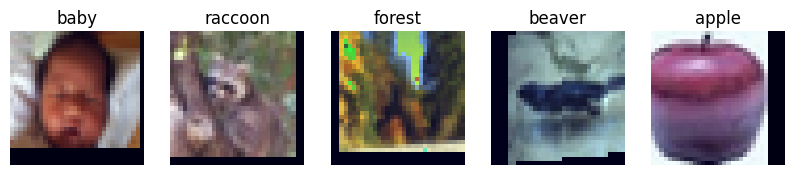

In [34]:
# visualise few samples
perm = torch.randperm(len(train_dataset))

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    img = train_dataset[perm[i]][0].permute(1, 2, 0)
    plt.imshow((img - img.min()) / (img.max() - img.min()))
    plt.title(train_dataset.classes[train_dataset[perm[i]][1]])
    plt.axis('off')

## Baseline Model

We'll use ResNet18 as a simple baseline

In [35]:
# Load pre-trained ResNet18 and modify for our dataset
# For CIFAR-100, we'll modify the first conv layer to handle 32x32 images
# For ImageNet (224x224), use standard ResNet18

num_classes = len(train_dataset.classes)

if hasattr(train_dataset, 'classes'):
    # CIFAR-100 or similar small dataset
    model = torchvision.models.resnet18(weights=None)  # Start from scratch
    # Modify first conv layer for smaller input
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()  # Remove maxpool for smaller images
    model.fc = nn.Linear(model.fc.in_features, num_classes)
else:
    # ImageNet
    model = torchvision.models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: {model}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Number of classes: {num_classes}")

Model: ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1

## Training Setup

Define loss function, optimizer, and learning rate scheduler.


In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=30,
    gamma=0.1
)

## Training and Evaluation Functions


In [37]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, leave=False)
    for inputs, targets in pbar:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
        pbar.set_description(f'Loss: {loss.item():.4f}, Acc: {100.*correct/total:.2f}%')
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, leave=False)
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            pbar.set_description(f'Loss: {loss.item():.4f}, Acc: {100.*correct/total:.2f}%')
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc



## Training Loop


In [38]:
num_epochs = 100  # Adjust as needed
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print(f"Starting training for {num_epochs} epochs...")
print(f"Batch size: {batch_size}")
print(f"Device: {device}\n")

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Learning rate: {scheduler.get_last_lr()[0]:.6f}')
    
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Update learning rate
    scheduler.step()
    
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    print('-' * 60)

Starting training for 100 epochs...
Batch size: 32
Device: cuda:7

Epoch 1/100
Learning rate: 0.001000


  0%|          | 0/1563 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

Train Loss: 4.1150, Train Acc: 7.07%
Val Loss: 3.5222, Val Acc: 15.54%
------------------------------------------------------------
Epoch 2/100
Learning rate: 0.001000


  0%|          | 0/1563 [00:00<?, ?it/s]

...

  0%|          | 0/313 [00:00<?, ?it/s]

Train Loss: 0.1517, Train Acc: 95.53%
Val Loss: 1.2912, Val Acc: 73.84%
------------------------------------------------------------
Epoch 100/100
Learning rate: 0.000001


  0%|          | 0/1563 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

Train Loss: 0.1518, Train Acc: 95.60%
Val Loss: 1.3054, Val Acc: 73.84%
------------------------------------------------------------


# AlexNet

In [48]:
class AlexNetCIFAR(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),      # 32 → 16

            nn.Conv2d(64, 192, 3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.MaxPool2d(2),      # 16 → 8

            nn.Conv2d(192, 384, 3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(),

            nn.Conv2d(384, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),      # 8 → 4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [49]:
alex_net = AlexNetCIFAR()
alex_net = alex_net.to(device)

# Count parameters
total_params = sum(p.numel() for p in alex_net.parameters())
trainable_params = sum(p.numel() for p in alex_net.parameters() if p.requires_grad)

print(f"Model: {alex_net}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Number of classes: {num_classes}")

Model: AlexNetCIFAR(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=

## Training Setup

Define loss function, optimizer, and learning rate scheduler.


In [50]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    alex_net.parameters(),
    lr=0.001
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=30,
    gamma=0.1
)

## Training Loop


In [51]:
num_epochs = 100  # Adjust as needed
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print(f"Starting training for {num_epochs} epochs...")
print(f"Batch size: {batch_size}")
print(f"Device: {device}\n")

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Learning rate: {scheduler.get_last_lr()[0]:.6f}')
    
    # Train
    train_loss, train_acc = train_one_epoch(alex_net, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    val_loss, val_acc = evaluate(alex_net, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Update learning rate
    scheduler.step()
    
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    print('-' * 60)

Starting training for 100 epochs...
Batch size: 32
Device: cuda:7

Epoch 1/100
Learning rate: 0.001000


  0%|          | 0/1563 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

Train Loss: 4.0717, Train Acc: 8.80%
Val Loss: 3.3543, Val Acc: 18.92%
------------------------------------------------------------
Epoch 2/100
Learning rate: 0.001000


  0%|          | 0/1563 [00:00<?, ?it/s]

...

  0%|          | 0/313 [00:00<?, ?it/s]

Train Loss: 0.8435, Train Acc: 75.05%
Val Loss: 1.1280, Val Acc: 69.87%
------------------------------------------------------------
Epoch 100/100
Learning rate: 0.000001


  0%|          | 0/1563 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

Train Loss: 0.8455, Train Acc: 74.99%
Val Loss: 1.1311, Val Acc: 69.67%
------------------------------------------------------------


# LUTAlexNet

AlexNet analogue built on LUT convolutions (`Conv2DLut`).
Architecture mirrors AlexNetCIFAR: 5 conv stages with the same channel widths
(64 → 192 → 384 → 256 → 256) and 3 MaxPool downsamples.
Since `Conv2DLut` uses no padding, each conv stage is preceded by
`nn.ZeroPad2d(1)` so the spatial dimensions follow the exact same path as
the original AlexNetCIFAR (32→16→8→8→8→4).


In [ ]:
from spiky.lutorch.multi_head_lut import Conv2DLut, UnfoldConfiguration


class LUTAlexNetCIFAR(nn.Module):
    """
    LUT-based analogue of AlexNetCIFAR for CIFAR-100 (32×32 input).

    Spatial flow (identical to AlexNetCIFAR):
      Input      [B,   3, 32, 32]
      pad+c1     [B,  64, 32, 32]  ← ZeroPad2d(1) makes input 34×34
      pool1      [B,  64, 16, 16]
      pad+c2     [B, 192, 16, 16]  ← ZeroPad2d(1) makes input 18×18
      pool2      [B, 192,  8,  8]
      pad+c3     [B, 384,  8,  8]  ← ZeroPad2d(1) makes input 10×10
      pad+c4     [B, 256,  8,  8]
      pad+c5     [B, 256,  8,  8]
      pool5      [B, 256,  4,  4]
      classifier [B, 100]

    n_anchor_pairs per layer is chosen to be well below
    patch_dim = in_channels * 9 so anchors can be sampled freely:
      c1: patch_dim=27,   n_anchor_pairs=4
      c2: patch_dim=576,  n_anchor_pairs=8
      c3: patch_dim=1728, n_anchor_pairs=10
      c4: patch_dim=3456, n_anchor_pairs=10
      c5: patch_dim=2304, n_anchor_pairs=10
    """

    def __init__(self, num_classes: int = 100, device=None):
        super().__init__()
        if device is None:
            device = torch.device('cpu')

        # ---- Stage 1: pad 32→34, conv 34→32, pool 32→16 ----
        self.pad1 = nn.ZeroPad2d(1)
        self.c1 = Conv2DLut(
            unfold_config=UnfoldConfiguration(H=34, W=34, kernel_size=3, stride=1),
            in_channels=3, out_channels=64,
            n_anchor_pairs=4,
            smooth_mode=True, n_alternatives=3,
            tables_per_head=8,
            initial_weights_noise=0.001,
            device=device,
        )
        self.pool1 = nn.MaxPool2d(2)

        # ---- Stage 2: pad 16→18, conv 18→16, pool 16→8 ----
        self.pad2 = nn.ZeroPad2d(1)
        self.c2 = Conv2DLut(
            unfold_config=UnfoldConfiguration(H=18, W=18, kernel_size=3, stride=1),
            in_channels=64, out_channels=192,
            n_anchor_pairs=8,
            smooth_mode=True, n_alternatives=3,
            tables_per_head=8,
            initial_weights_noise=0.001,
            device=device,
        )
        self.pool2 = nn.MaxPool2d(2)

        # ---- Stage 3: pad 8→10, conv 10→8, no pool ----
        self.pad3 = nn.ZeroPad2d(1)
        self.c3 = Conv2DLut(
            unfold_config=UnfoldConfiguration(H=10, W=10, kernel_size=3, stride=1),
            in_channels=192, out_channels=384,
            n_anchor_pairs=10,
            smooth_mode=True, n_alternatives=3,
            tables_per_head=8,
            initial_weights_noise=0.001,
            device=device,
        )

        # ---- Stage 4: pad 8→10, conv 10→8, no pool ----
        self.pad4 = nn.ZeroPad2d(1)
        self.c4 = Conv2DLut(
            unfold_config=UnfoldConfiguration(H=10, W=10, kernel_size=3, stride=1),
            in_channels=384, out_channels=256,
            n_anchor_pairs=10,
            smooth_mode=True, n_alternatives=3,
            tables_per_head=8,
            initial_weights_noise=0.001,
            device=device,
        )

        # ---- Stage 5: pad 8→10, conv 10→8, pool 8→4 ----
        self.pad5 = nn.ZeroPad2d(1)
        self.c5 = Conv2DLut(
            unfold_config=UnfoldConfiguration(H=10, W=10, kernel_size=3, stride=1),
            in_channels=256, out_channels=256,
            n_anchor_pairs=10,
            smooth_mode=True, n_alternatives=3,
            tables_per_head=8,
            initial_weights_noise=0.001,
            device=device,
        )
        self.pool5 = nn.MaxPool2d(2)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool1(self.c1(self.pad1(x)))   # [B,  64, 16, 16]
        x = self.pool2(self.c2(self.pad2(x)))   # [B, 192,  8,  8]
        x = self.c3(self.pad3(x))               # [B, 384,  8,  8]
        x = self.c4(self.pad4(x))               # [B, 256,  8,  8]
        x = self.pool5(self.c5(self.pad5(x)))   # [B, 256,  4,  4]
        return self.classifier(x)               # [B, 100]

In [ ]:
lut_alex = LUTAlexNetCIFAR(num_classes=num_classes, device=device)

total_params = sum(p.numel() for p in lut_alex.parameters())
trainable_params = sum(p.numel() for p in lut_alex.parameters() if p.requires_grad)
print(f"LUTAlexNet")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Number of classes: {num_classes}")

## Training Setup

In [ ]:
lut_alex_criterion = nn.CrossEntropyLoss()
lut_alex_optimizer = torch.optim.Adam(lut_alex.parameters(), lr=0.001)
lut_alex_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    lut_alex_optimizer, T_max=100
)

## Training Loop

In [ ]:
lut_alex_num_epochs = 100
lut_alex_train_losses = []
lut_alex_train_accs = []
lut_alex_val_losses = []
lut_alex_val_accs = []

print(f"Starting LUTAlexNet training for {lut_alex_num_epochs} epochs...")
print(f"Batch size: {batch_size}")
print(f"Device: {device}\n")

for epoch in range(lut_alex_num_epochs):
    print(f'LUTAlexNet Epoch {epoch+1}/{lut_alex_num_epochs}')
    print(f'Learning rate: {lut_alex_scheduler.get_last_lr()[0]:.6f}')

    train_loss, train_acc = train_one_epoch(
        lut_alex, train_loader, lut_alex_criterion, lut_alex_optimizer, device
    )
    lut_alex_train_losses.append(train_loss)
    lut_alex_train_accs.append(train_acc)

    val_loss, val_acc = evaluate(lut_alex, val_loader, lut_alex_criterion, device)
    lut_alex_val_losses.append(val_loss)
    lut_alex_val_accs.append(val_acc)

    lut_alex_scheduler.step()

    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    print('-' * 60)

## Plot Results

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(lut_alex_train_losses, label='Train Loss', color='blue')
ax1.plot(lut_alex_val_losses, label='Val Loss', color='red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('LUTAlexNet Training and Validation Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(lut_alex_train_accs, label='Train Acc', color='blue')
ax2.plot(lut_alex_val_accs, label='Val Acc', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('LUTAlexNet Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

if len(lut_alex_val_accs) > 0:
    print(f"LUTAlexNet Best val accuracy: {max(lut_alex_val_accs):.2f}% at epoch {lut_alex_val_accs.index(max(lut_alex_val_accs))+1}")

## Plot Results


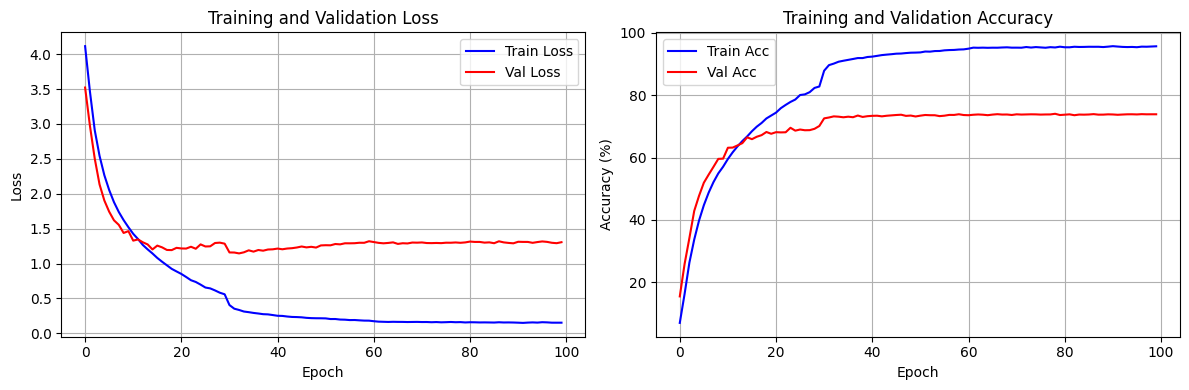

Best validation accuracy: 74.00% at epoch 79


In [39]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(val_losses, label='Val Loss', color='red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(train_accs, label='Train Acc', color='blue')
ax2.plot(val_accs, label='Val Acc', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {max(val_accs):.2f}% at epoch {val_accs.index(max(val_accs))+1}")